#📌 Extracão

In [1]:
import pandas as pd

# URL da base
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

# Extraindo os dados
df_telecom = pd.read_json(url)

# Visualização inicial
print("Tamanho do dataset:", df_telecom.shape)
df_telecom.head()

Tamanho do dataset: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [2]:
# 1. Normalização das colunas aninhadas
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# 2. Junção em um DataFrame limpo
df_clean = pd.concat([df_telecom[['customerID', 'Churn']],
                      df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Tratamento de Inconsistências (O ponto chave!)
# Transformando Charges.Total em número
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# No projeto de referência, vimos que os nulos em Charges.Total são clientes com 0 meses de contrato.
# Em vez de apagar, vamos preencher com 0.
df_clean['Charges.Total'] = df_clean['Charges.Total'].fillna(0)

# Removendo linhas onde o Churn está vazio (strings vazias)
df_clean = df_clean[df_clean['Churn'] != ''].copy()

# 4. Padronização (Tradução e Binários)
mapa_evasao = {'No': 0, 'Yes': 1}
df_clean['Churn'] = df_clean['Churn'].map(mapa_evasao)

colunas_novas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'tenure': 'Meses_Contrato',
    'Contract': 'Contrato',
    'Charges.Monthly': 'Faturamento_Mensal',
    'Charges.Total': 'Faturamento_Total'
}
df_clean.rename(columns=colunas_novas, inplace=True)

# 5. Coluna de Contas Diárias (Opcional)
df_clean['Contas_Diarias'] = (df_clean['Faturamento_Mensal'] / 30).round(2)

print("Inconsistências tratadas com sucesso!")
df_clean.info()

Inconsistências tratadas com sucesso!
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Cliente          7043 non-null   object 
 1   Evasao              7043 non-null   int64  
 2   Genero              7043 non-null   object 
 3   Idoso               7043 non-null   int64  
 4   Partner             7043 non-null   object 
 5   Dependents          7043 non-null   object 
 6   Meses_Contrato      7043 non-null   int64  
 7   PhoneService        7043 non-null   object 
 8   MultipleLines       7043 non-null   object 
 9   InternetService     7043 non-null   object 
 10  OnlineSecurity      7043 non-null   object 
 11  OnlineBackup        7043 non-null   object 
 12  DeviceProtection    7043 non-null   object 
 13  TechSupport         7043 non-null   object 
 14  StreamingTV         7043 non-null   object 
 15  StreamingMovies     70

In [8]:
print("Estatísticas Descritivas das Variáveis Numéricas:")
display(df_clean.describe())

print("\nMediana das variáveis numéricas:")
display(df_clean[['Meses_Contrato', 'Faturamento_Mensal', 'Faturamento_Total']].median())

Estatísticas Descritivas das Variáveis Numéricas:


,Evasao,Idoso,Meses_Contrato,Faturamento_Mensal,Faturamento_Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692,2279.734304,2.158675
std,0.441561,0.368612,24.559481,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,9.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,29.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,55.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.960000



Mediana das variáveis numéricas:


,0
Meses_Contrato,29.00
Faturamento_Mensal,70.35
Faturamento_Total,1394.55


In [9]:
total_duplicados = df_clean.duplicated().sum()
print(f"Total de registros duplicados encontrados: {total_duplicados}")

# Se houver duplicados, você pode removê-los com:
# df_clean.drop_duplicates(inplace=True)

Total de registros duplicados encontrados: 0


#📊 Carga e análise

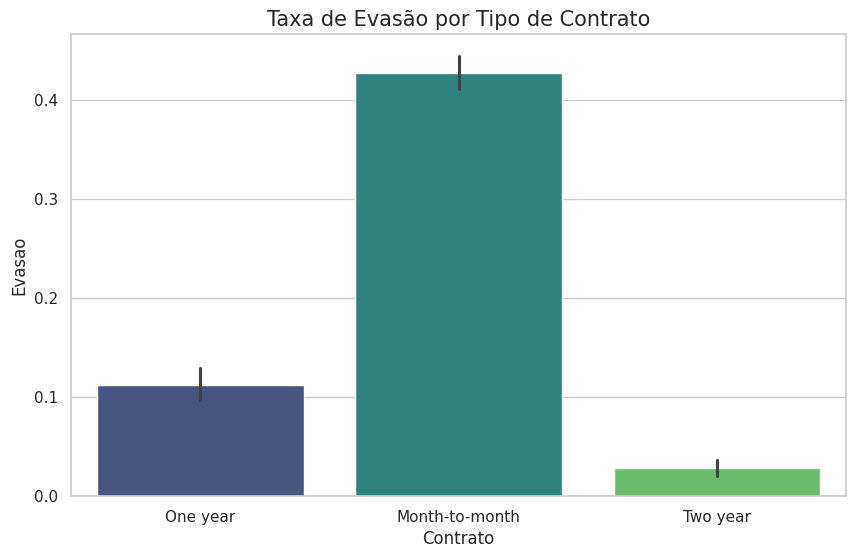

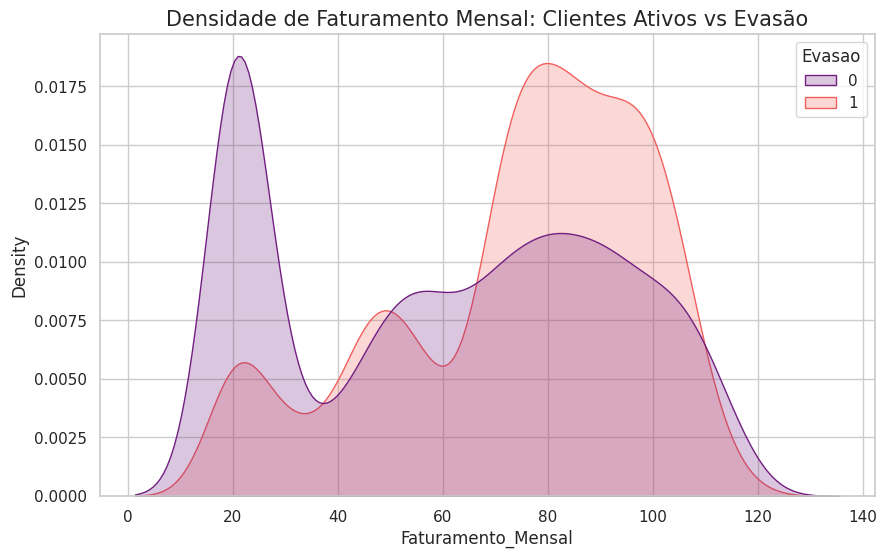

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Visualização 1: Evasão por Tipo de Contrato
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='Contrato', y='Evasao', palette='viridis', hue='Contrato', legend=False)
plt.title('Taxa de Evasão por Tipo de Contrato', fontsize=15)
plt.show()

# Visualização 2: Distribuição de Faturamento Mensal vs Evasão
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x="Faturamento_Mensal", hue="Evasao", fill=True, common_norm=False, palette='magma')
plt.title('Densidade de Faturamento Mensal: Clientes Ativos vs Evasão', fontsize=15)
plt.show()

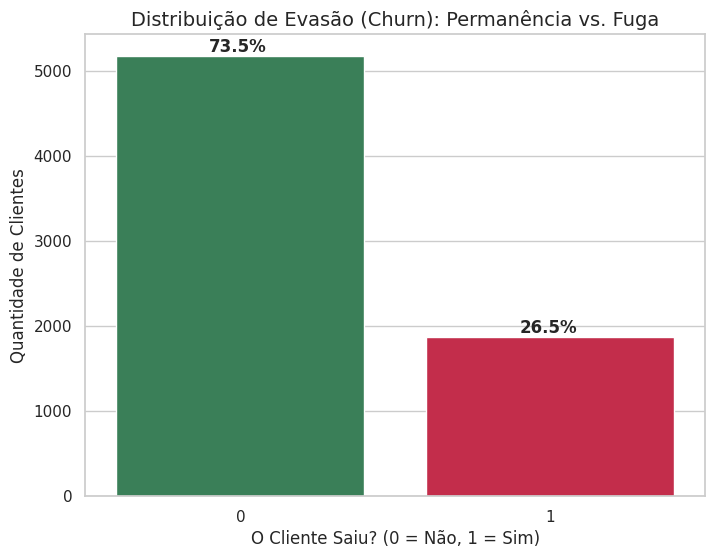

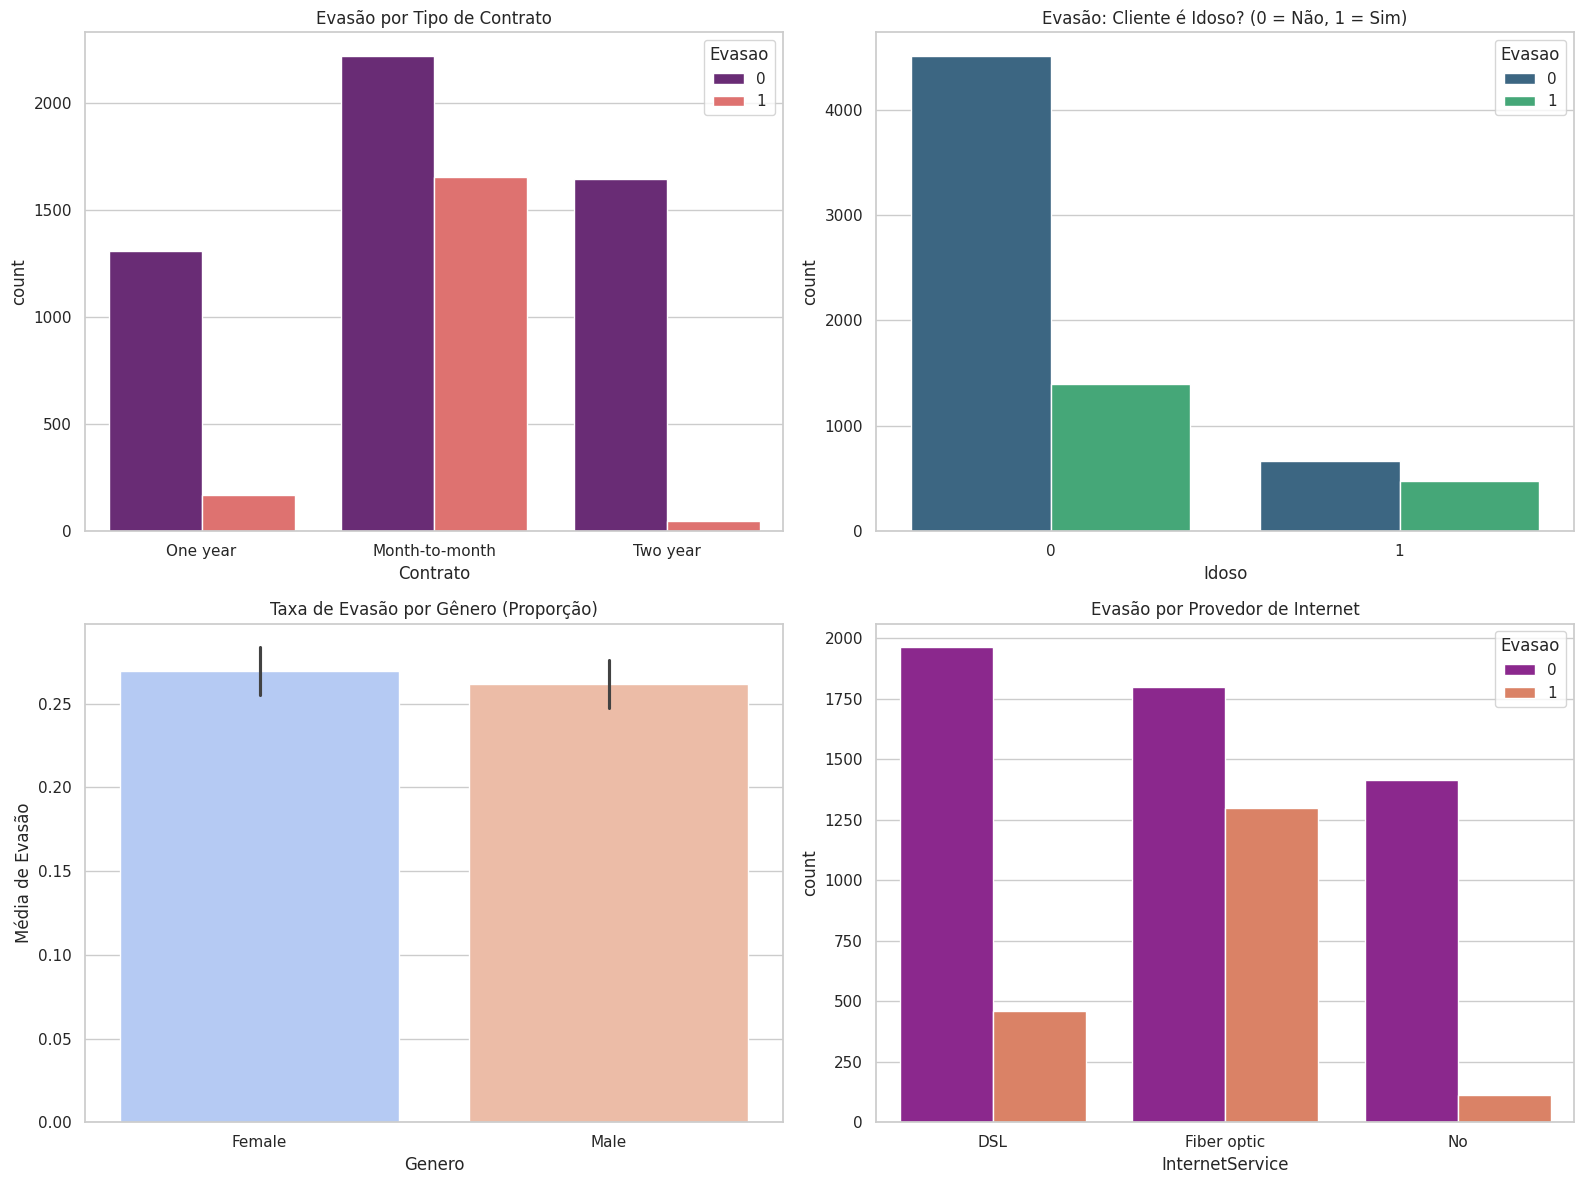

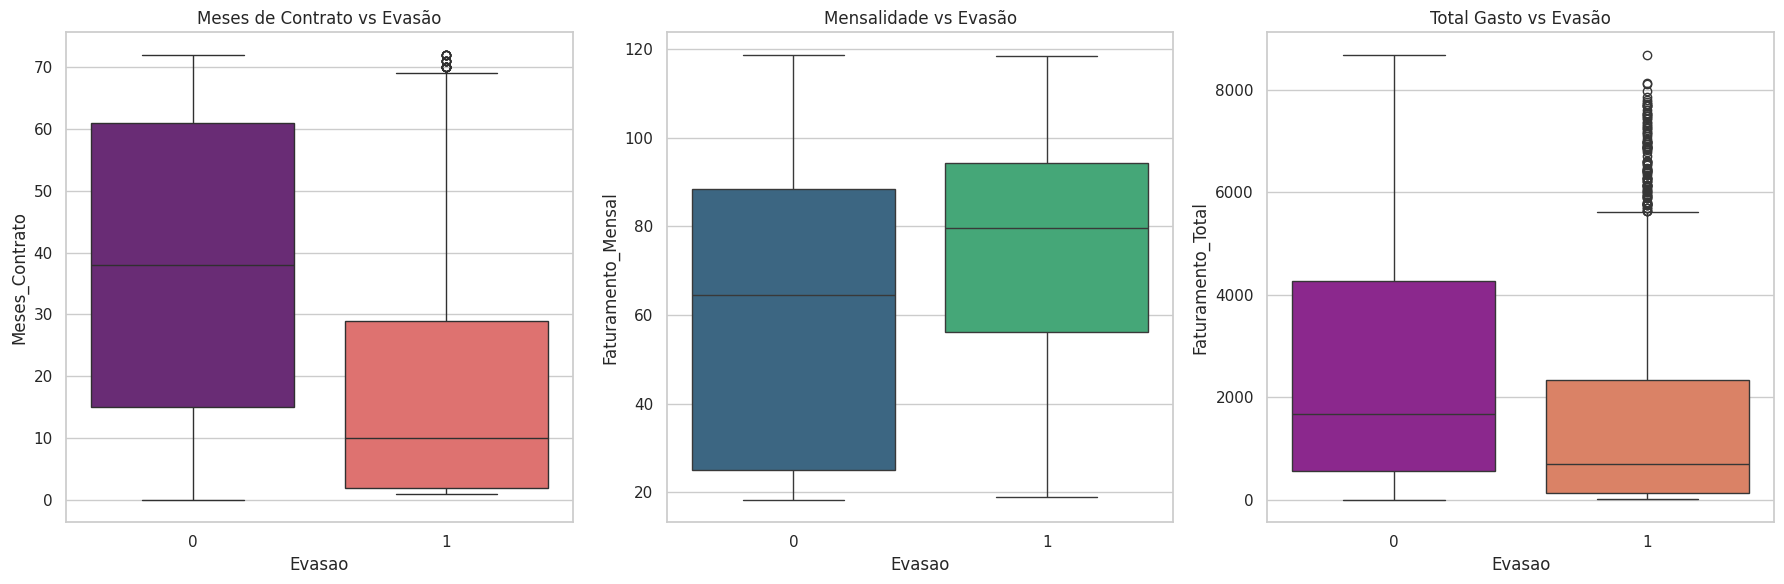

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurando o estilo profissional
sns.set_theme(style="whitegrid")

# --- 1. O PANORAMA GERAL ---
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_clean, x='Evasao', palette={0: 'seagreen', 1: 'crimson'}, hue='Evasao', legend=False)
plt.title('Distribuição de Evasão (Churn): Permanência vs. Fuga', fontsize=14)
plt.xlabel('O Cliente Saiu? (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Adicionando porcentagens para dar contexto de negócio
total = len(df_clean['Evasao'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')
plt.show()

# --- 2. OS VILÕES CATEGÓRICOS ---
# Aqui descobrimos quais serviços ou contratos estão "expulsando" o cliente
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Evasão por Tipo de Contrato (O maior influenciador)
sns.countplot(data=df_clean, x='Contrato', hue='Evasao', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Evasão por Tipo de Contrato')

# Evasão por Idoso (Verificando vulnerabilidade do público)
sns.countplot(data=df_clean, x='Idoso', hue='Evasao', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Evasão: Cliente é Idoso? (0 = Não, 1 = Sim)')

# 3. Evasão por Gênero (Ajustado para mostrar a TAXA de evasão, não apenas o total bruto)
sns.barplot(data=df_clean, x='Genero', y='Evasao', ax=axes[1, 0], palette='coolwarm', hue='Genero', legend=False)
axes[1, 0].set_title('Taxa de Evasão por Gênero (Proporção)')
axes[1, 0].set_ylabel('Média de Evasão')
# Evasão por Internet (Fibra Óptica costuma ter alto churn se for cara/ruim)
# Nota: Ajuste o nome da coluna se você não traduziu 'InternetService'
if 'InternetService' in df_clean.columns:
    sns.countplot(data=df_clean, x='InternetService', hue='Evasao', ax=axes[1, 1], palette='plasma')
    axes[1, 1].set_title('Evasão por Provedor de Internet')

plt.tight_layout()
plt.show()

# --- 3. O RASTRO FINANCEIRO (BOXPLOTS) ---
# Aqui vemos se o preço alto ou o pouco tempo de casa influenciam na saída
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Meses_Contrato: Quanto mais tempo, menor o churn?
sns.boxplot(data=df_clean, x='Evasao', y='Meses_Contrato', palette='magma', ax=axes[0], hue='Evasao', legend=False)
axes[0].set_title('Meses de Contrato vs Evasão');

# Faturamento_Mensal: Clientes que pagam mais saem mais?
sns.boxplot(data=df_clean, x='Evasao', y='Faturamento_Mensal', palette='viridis', ax=axes[1], hue='Evasao', legend=False)
axes[1].set_title('Mensalidade vs Evasão');

# Faturamento_Total: Qual o prejuízo acumulado?
sns.boxplot(data=df_clean, x='Evasao', y='Faturamento_Total', palette='plasma', ax=axes[2], hue='Evasao', legend=False)
axes[2].set_title('Total Gasto vs Evasão');

plt.tight_layout()
plt.show()

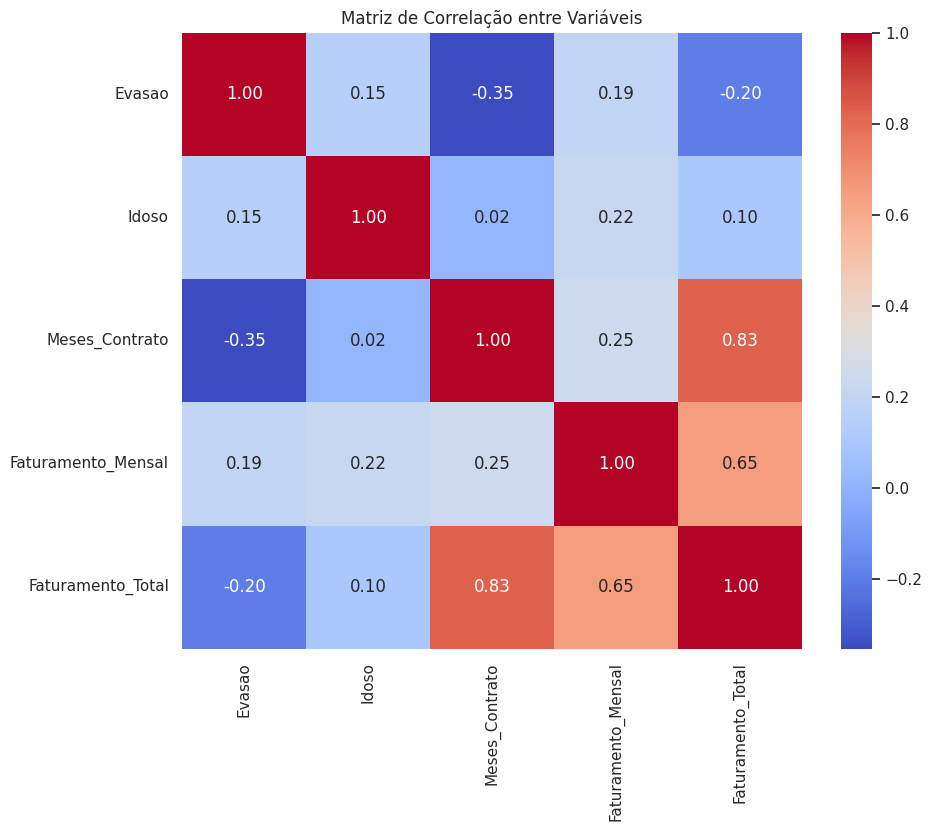

In [10]:
plt.figure(figsize=(10, 8))

corr = df_clean[['Evasao', 'Idoso', 'Meses_Contrato', 'Faturamento_Mensal', 'Faturamento_Total']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

In [11]:
# 1. Salvando o DataFrame como CSV dentro do Colab
# index=False serve para não criar aquela coluna extra de números no começo
df_clean.to_csv('TelecomX_Dados_Limpos.csv', index=False, encoding='utf-8')

# 2. Comando para baixar o arquivo direto para o seu computador
from google.colab import files
files.download('TelecomX_Dados_Limpos.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#📄 Relatório Final: Estratégia de Retenção Telecom X



## # 1. Introdução
O objetivo desta análise foi investigar a taxa de evasão (Churn) da Telecom X, que atualmente atinge 26,5% da base. Identificar os gargalos na jornada do cliente é vital para estancar a perda de receita e melhorar a saúde financeira da operação.

2. Limpeza e Tratamento de Dados
Os dados brutos em JSON foram normalizados para uma estrutura tabular. Realizamos o tratamento de inconsistências críticas, como a conversão de Charges.Total para numérico. Optamos por preencher valores nulos com 0 para clientes com tenure 0, garantindo que novos usuários não fossem excluídos da análise. Registros sem status de evasão foram removidos para garantir a integridade estatística.

3. Análise Exploratória (Insights Chave)
Barreira Contratual: Clientes sem fidelidade (mensais) apresentam churn de 42,7%, contra apenas 2,8% em contratos de dois anos.

Ticket Médio Elevado: A evasão é maior entre clientes com mensalidades superiores a R$ 79,65, indicando uma baixa percepção de custo-benefício.

O Vale da Morte: A mediana de retenção para quem cancela é de 10 meses, mostrando que a empresa falha em fidelizar o cliente no primeiro ano de uso.

4. Conclusões
A análise descarta fatores demográficos (como gênero) como causas de churn. O problema é estrutural e de produto: a facilidade de saída do contrato mensal somada a um ticket médio alto na Fibra Óptica cria o cenário ideal para a fuga de clientes novos.

5. Recomendações Estratégicas
Migração Incentivada: Criar campanhas de marketing oferecendo "upgrade" de velocidade ou descontos progressivos para migrar clientes do plano mensal para o anual.

Onboarding de Elite: Implementar um programa de monitoramento intensivo nos primeiros 12 meses, com suporte prioritário para novos assinantes.

Revisão da Fibra Óptica: Realizar uma pesquisa de satisfação focada especificamente em usuários de Fibra para entender se o churn é causado por instabilidade técnica ou preço abusivo.